In [47]:
import requests
import time
import pandas as pd

apis = {
    "JSONPlaceholder": "https://jsonplaceholder.typicode.com/posts/1",
    "DummyJSON": "https://dummyjson.com/posts/1"
}

results = []

for api_name, url in apis.items():
    for run in range(30):
        start = time.perf_counter()

        try:
            response = requests.get(url, timeout=10)
            end = time.perf_counter()

            latency_ms = (end - start) * 1000

            results.append({
                "api": api_name,
                "run": run + 1,
                "latency_ms": latency_ms,
                "status_code": response.status_code,
                "success": response.status_code == 200
            })

        except Exception as e:
            results.append({
                "api": api_name,
                "run": run + 1,
                "latency_ms": None,
                "status_code": None,
                "success": False
            })

df = pd.DataFrame(results)

df

,api,run,latency_ms,status_code,success
0,JSONPlaceholder,1,50.412347,200,True
1,JSONPlaceholder,2,55.760267,200,True
2,JSONPlaceholder,3,38.852258,200,True
3,JSONPlaceholder,4,39.100972,200,True
4,JSONPlaceholder,5,47.124387,200,True
5,JSONPlaceholder,6,43.198385,200,True
6,JSONPlaceholder,7,36.413411,200,True
7,JSONPlaceholder,8,45.672214,200,True
8,JSONPlaceholder,9,36.725884,200,True
9,JSONPlaceholder,10,46.204814,200,True


In [48]:
summary = df.groupby("api").agg(
    average_latency_ms=("latency_ms", "mean"),
    median_latency_ms=("latency_ms", "median"),
    successful_requests=("success", "sum"),
    total_requests=("success", "count")
)

summary["success_rate_percent"] = (
    summary["successful_requests"] /
    summary["total_requests"] * 100
)

summary

,average_latency_ms,median_latency_ms,successful_requests,total_requests,success_rate_percent
api,,,,,
DummyJSON,216.744485,214.539346,30,30,100.0
JSONPlaceholder,46.790548,44.460092,30,30,100.0


In [49]:
df.to_csv("raw_results.csv", index=False)
summary.to_csv("summary_results.csv")

In [50]:
summary = df.groupby("api").agg(
    average_latency_ms=("latency_ms", "mean"),
    median_latency_ms=("latency_ms", "median"),
    minimum_latency_ms=("latency_ms", "min"),
    maximum_latency_ms=("latency_ms", "max"),
    successful_requests=("success", "sum"),
    total_requests=("success", "count")
)

summary["success_rate_percent"] = (
    summary["successful_requests"] /
    summary["total_requests"] * 100
)

summary = summary.round(2)

summary

,average_latency_ms,median_latency_ms,minimum_latency_ms,maximum_latency_ms,successful_requests,total_requests,success_rate_percent
api,,,,,,,
DummyJSON,216.74,214.54,194.59,260.99,30,30,100.0
JSONPlaceholder,46.79,44.46,34.91,139.13,30,30,100.0


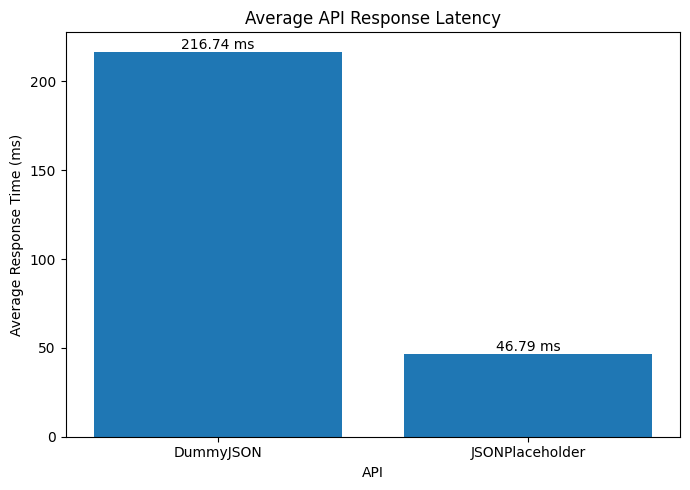

In [51]:
import matplotlib.pyplot as plt

average_latency = df.groupby("api")["latency_ms"].mean()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    average_latency.index,
    average_latency.values
)

plt.ylabel("Average Response Time (ms)")
plt.xlabel("API")
plt.title("Average API Response Latency")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f} ms",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "average_latency_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
df.to_csv("raw_results.csv", index=False)
summary.to_csv("summary_results.csv")

print("Files saved successfully.")

Files saved successfully.


In [53]:
import requests
import time
import pandas as pd

apis = {
    "JSONPlaceholder": "https://jsonplaceholder.typicode.com/posts/1",
    "DummyJSON": "https://dummyjson.com/posts/1"
}

results_v2 = []

for run in range(1, 31):

    for api_name, url in apis.items():

        start = time.perf_counter()

        try:
            response = requests.get(url, timeout=10)
            end = time.perf_counter()

            latency_ms = (end - start) * 1000

            results_v2.append({
                "api": api_name,
                "run": run,
                "latency_ms": latency_ms,
                "status_code": response.status_code,
                "success": response.status_code == 200
            })

        except Exception:
            results_v2.append({
                "api": api_name,
                "run": run,
                "latency_ms": None,
                "status_code": None,
                "success": False
            })

        time.sleep(0.5)

df_v2 = pd.DataFrame(results_v2)

df_v2

,api,run,latency_ms,status_code,success
0,JSONPlaceholder,1,39.576242,200,True
1,DummyJSON,1,218.570752,200,True
2,JSONPlaceholder,2,50.927136,200,True
3,DummyJSON,2,227.928115,200,True
4,JSONPlaceholder,3,46.787188,200,True
5,DummyJSON,3,209.387241,200,True
6,JSONPlaceholder,4,46.481605,200,True
7,DummyJSON,4,228.757500,200,True
8,JSONPlaceholder,5,47.925961,200,True
9,DummyJSON,5,211.716733,200,True


In [54]:
summary_v2 = df_v2.groupby("api").agg(
    average_latency_ms=("latency_ms", "mean"),
    median_latency_ms=("latency_ms", "median"),
    minimum_latency_ms=("latency_ms", "min"),
    maximum_latency_ms=("latency_ms", "max"),
    standard_deviation_ms=("latency_ms", "std"),
    successful_requests=("success", "sum"),
    total_requests=("success", "count")
)

summary_v2["success_rate_percent"] = (
    summary_v2["successful_requests"] /
    summary_v2["total_requests"] * 100
)

summary_v2 = summary_v2.round(2)

summary_v2

,average_latency_ms,median_latency_ms,minimum_latency_ms,maximum_latency_ms,standard_deviation_ms,successful_requests,total_requests,success_rate_percent
api,,,,,,,,
DummyJSON,224.42,225.19,200.42,249.60,13.14,30,30,100.0
JSONPlaceholder,45.05,44.56,37.19,64.43,6.56,30,30,100.0


In [55]:
std_result = df_v2.groupby("api")["latency_ms"].std().round(2)

std_result

,latency_ms
api,
DummyJSON,13.14
JSONPlaceholder,6.56


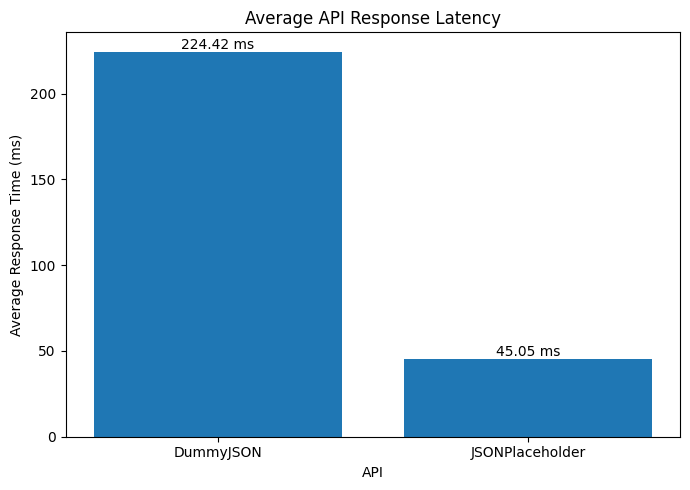

In [56]:
import matplotlib.pyplot as plt

average_latency = df_v2.groupby("api")["latency_ms"].mean()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    average_latency.index,
    average_latency.values
)

plt.ylabel("Average Response Time (ms)")
plt.xlabel("API")
plt.title("Average API Response Latency")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f} ms",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("average_latency_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
df_v2.to_csv("raw_results.csv", index=False)
summary_v2.to_csv("summary_results.csv")

print("Files saved.")

Files saved.


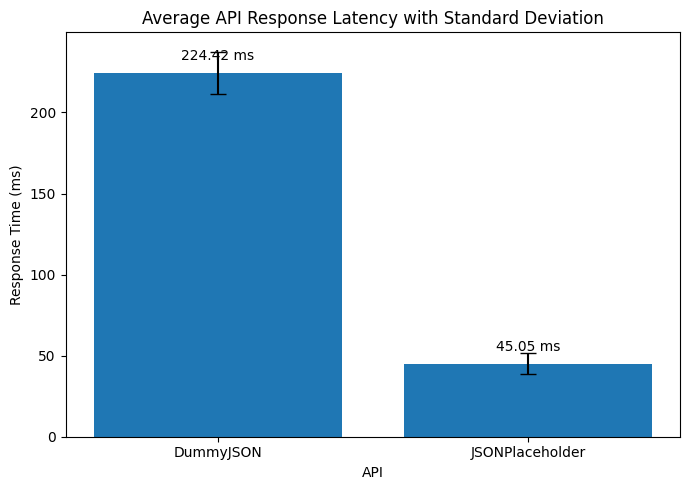

In [58]:
import matplotlib.pyplot as plt

summary_plot = df_v2.groupby("api")["latency_ms"].agg(["mean", "std"])

plt.figure(figsize=(7, 5))

bars = plt.bar(
    summary_plot.index,
    summary_plot["mean"],
    yerr=summary_plot["std"],
    capsize=6
)

plt.ylabel("Response Time (ms)")
plt.xlabel("API")
plt.title("Average API Response Latency with Standard Deviation")

for bar, value in zip(bars, summary_plot["mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 8,
        f"{value:.2f} ms",
        ha="center"
    )

plt.tight_layout()
plt.savefig("api_latency_with_std.png", dpi=300, bbox_inches="tight")
plt.show()

In [59]:
df_v2.to_csv("raw_results.csv", index=False)
summary_v2.to_csv("summary_results.csv")